In [1]:
import numpy as np
import rasterio
import pandas as pd
from pyproj import Transformer

import matplotlib.pyplot as plt

# Slope Calculation from TIFF

The goal of this notebook is to calculate a climb's ATES class with a rules-based approach. The climbs' ratings available in the [Ice Climbing Atlas](https://avalanche.ca/resources/ice-climbing/atlas) will validate this tool.

Data downloaded from https://portal.opentopography.org/raster?opentopoID=OTSDEM.032025.3979.1

## Polar Circus

https://avalanche.ca/resources/ice-climbing/atlas/polar-circus

In [2]:
def extract_tiff(path):
    with rasterio.open(path) as src:
        dem = src.read(1).astype(float)

        return {
            "dem": dem,
            "transform": src.transform,
            "height": src.height,
            "width": src.width,
            "crs": src.crs,
            "res": src.res,  # metres per pixel
        }


tiff = extract_tiff("../data/polar-circus/output_be.tif")

transform = tiff["transform"]
dem = tiff["dem"]

x_coords = transform.c + transform.a * np.arange(tiff["width"])
y_coords = transform.f + transform.e * np.arange(tiff["height"])
X, Y = np.meshgrid(x_coords, y_coords)

In [3]:
dem.shape

(105, 355)

In [4]:
tiff["res"]

(30.0, 30.0)

In [5]:
transform

Affine(30.0, 0.0, -1463640.0,
       0.0, -30.0, 603870.0)

In [6]:
x_coords[:5]

array([-1463640., -1463610., -1463580., -1463550., -1463520.])

In [7]:
y_coords[:5]

array([603870., 603840., 603810., 603780., 603750.])

### Convert to Lat/Lng


In [8]:
transformer = Transformer.from_crs(tiff["crs"], "EPSG:4326", always_xy=True)
lons, lats = transformer.transform(X, Y)


In [9]:
lats[0][:5], lons[0][:5]

(array([52.1420182 , 52.14211085, 52.14220349, 52.14229614, 52.14238878]),
 array([-117.05631912, -117.05590241, -117.0554857 , -117.05506899,
        -117.05465228]))

### Slope


In [10]:
def calculate_slope(tiff):
    res_y, res_x = tiff["res"]
    dy, dx = np.gradient(tiff["dem"], res_y, res_x)
    return np.degrees(np.arctan(np.sqrt(dx**2 + dy**2)))


slope_deg = calculate_slope(tiff)
slope_deg

array([[33.14817536, 34.011723  , 35.00803503, ...,  8.77726116,
         7.61822436,  8.4927507 ],
       [34.03177061, 34.61704548, 35.1477009 , ..., 10.50509769,
         7.34166651,  6.94590057],
       [35.39157968, 35.52367853, 35.18894912, ..., 12.27828153,
         8.05164666,  5.83097124],
       ...,
       [ 8.49277621,  8.41515426,  8.92334812, ..., 18.68844623,
        16.60185316, 15.86719048],
       [ 8.53566228,  8.09239316,  7.99171378, ..., 21.74807016,
        18.73029424, 17.31810569],
       [ 8.8717231 ,  8.28047147,  7.94301604, ..., 24.43635174,
        20.78667777, 18.94710086]], shape=(105, 355))

## Plot 

### Elevation

In [11]:
def plot_contour(X: np.ndarray, Y: np.ndarray, title: str, levels: int = 50):
    _, ax = plt.subplots(figsize=(12, 4))
    contour = ax.contourf(X, Y, dem, levels=60, cmap="terrain")
    contour_lines = ax.contour(
        X, Y, dem, levels=levels, colors="black", linewidths=0.5, alpha=0.5
    )
    plt.colorbar(contour, ax=ax, label="Elevation (m)")
    ax.clabel(contour_lines, inline=True, fontsize=7, fmt="%.0f")
    ax.set_title(title)
    ax.set_aspect("equal")
    plt.tight_layout()
    plt.show()

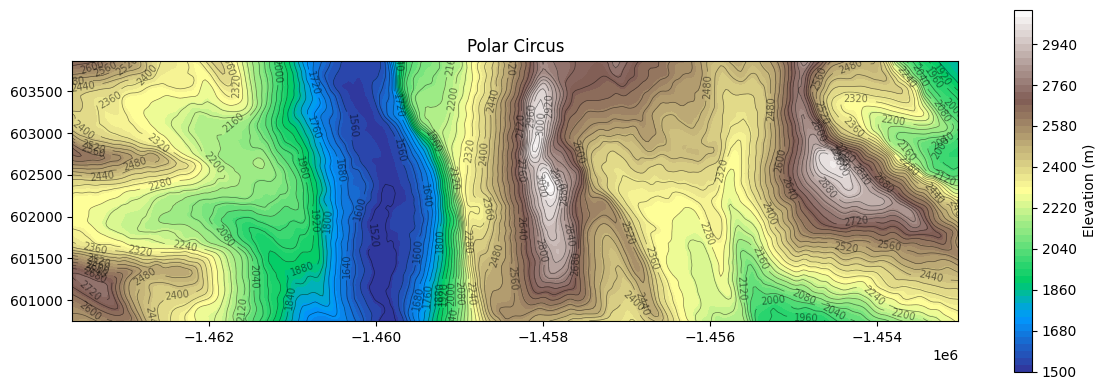

In [12]:
plot_contour(X, Y, "Polar Circus")

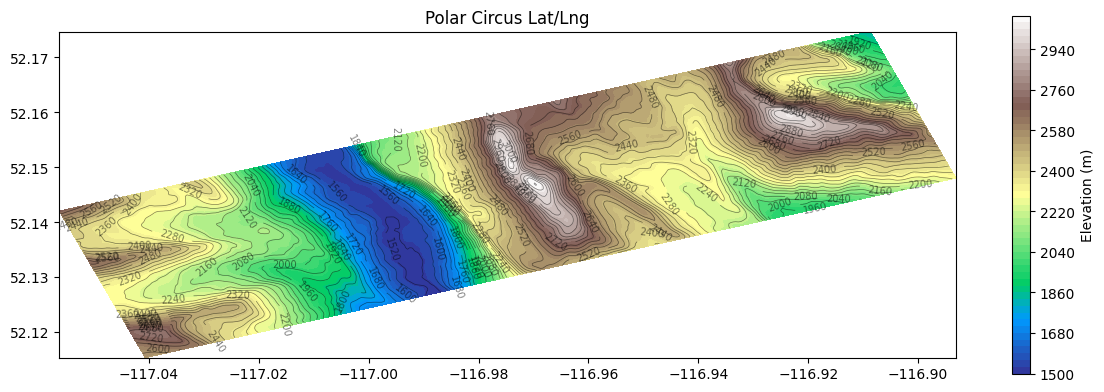

In [13]:
plot_contour(lons, lats, "Polar Circus Lat/Lng")

### Slope

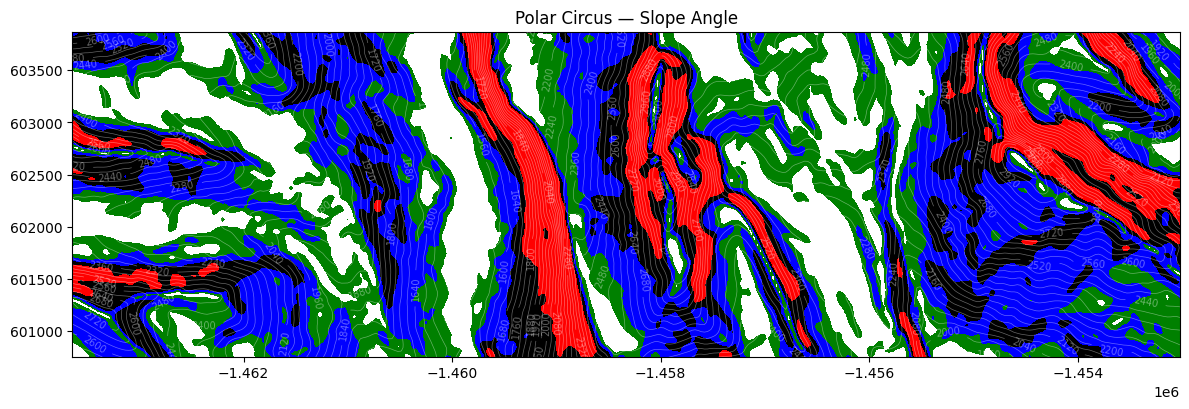

In [14]:
from matplotlib.colors import BoundaryNorm, ListedColormap


def plot_slope(X, Y, title: str):
    cmap = ListedColormap(["none", "green", "blue", "black", "red"])
    bounds = [0, 15, 25, 35, 45, 90]
    norm = BoundaryNorm(bounds, cmap.N)

    _, ax = plt.subplots(figsize=(12, 4))
    ax.contourf(X, Y, slope_deg, levels=bounds, cmap=cmap, norm=norm)
    contour_lines = ax.contour(
        X, Y, dem, levels=50, colors="white", linewidths=0.5, alpha=0.4
    )
    ax.clabel(contour_lines, inline=True, fontsize=7, fmt="%.0f", colors="white")
    ax.set_title(title)
    ax.set_aspect("equal")
    plt.tight_layout()
    plt.show()


plot_slope(X, Y, "Polar Circus — Slope Angle")